# Implementation of MCP Neuron for AND and OR Function.

## Step - 2.5 - Normalize the Data

In [12]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  state_neuron = []

  for i in range(len(X1)):
        s = X1[i] + X2[i]   # element-wise sum

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

  return state_neuron

In [13]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [14]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]   # element-wise sum

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [15]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Fill NaN values with 0 (assuming missing pixels should be black)
df_0_1 = df_0_1.fillna(0)

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Normalize the pixel values from 0-255 to 0-1
X = X / 255.0

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Data normalized. Min value: ", X.min(), ", Max value: ", X.max())

Feature matrix shape: (9875, 784)
Label vector shape: (9875,)
Data normalized. Min value:  0.0 , Max value:  1.0


### Viewing the Dataset.

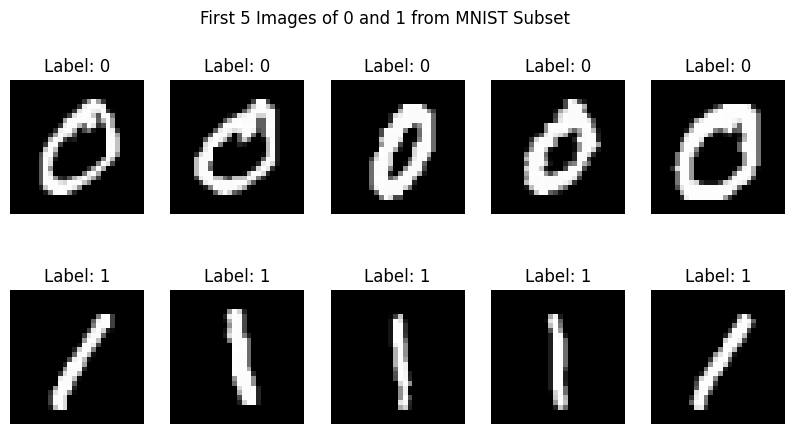

In [18]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [19]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [20]:
def decision_function(X, weights, bias):
    """
    Predict class labels for all samples in X using a step activation function.

    Parameters:
      X       (ndarray): Feature matrix of shape (n_samples, n_features)
      weights (ndarray): Weight vector of shape (n_features,)
      bias    (float)  : Bias scalar

    Returns:
      y_pred_all (ndarray): Predicted labels (0 or 1) of shape (n_samples,)
    """
    # Compute raw scores (weighted sum + bias)
    predictions = np.dot(X, weights) + bias

    # Apply step activation function:
    # output 1 if prediction >= 0, else output 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [21]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    n_samples, n_features = X.shape

    for _ in range(epochs):
        # Shuffle the data for each epoch to improve convergence
        # (Optional, but good practice)
        # shuffled_indices = np.random.permutation(n_samples)
        # X_shuffled = X[shuffled_indices]
        # y_shuffled = y[shuffled_indices]

        for i in range(n_samples):
            # Make a prediction using the current weights and bias
            # Reshape X[i] to (1, -1) to make it 2D for decision_function
            prediction = decision_function(X[i].reshape(1, -1), weights, bias)[0]

            # Update weights and bias based on misclassification
            if y[i] == 1 and prediction == 0:  # False Negative
                weights += learning_rate * X[i]
                bias += learning_rate
            elif y[i] == 0 and prediction == 1:  # False Positive
                weights -= learning_rate * X[i]
                bias -= learning_rate
            # If correctly classified (y[i] == prediction), no update is needed

    # Calculate accuracy after all epochs
    final_predictions = decision_function(X, weights, bias)
    accuracy = np.mean(final_predictions == y)

    return weights, bias, accuracy

## Training the Perceptron

In [22]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [23]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

# To always visualize some images, even if correctly classified, we could modify this section.
# For now, let's keep the original logic which only plots if there are misclassifications.

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# Implementation for 3 Vs. 5 Classification.

## Step 1: Load the Dataset (3s and 5s)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset for 3s and 5s
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI/mnist_3_and_5.csv")

# Fill NaN values with 0 (assuming missing pixels should be black)
df_3_5 = df_3_5.fillna(0)

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values  # 784 pixels
y_35 = df_3_5["label"].values  # Labels (3 or 5)

# Normalize the pixel values from 0-255 to 0-1
X_35 = X_35 / 255.0

# Convert labels 3 to 0 and 5 to 1 for binary classification
y_35_binary = np.where(y_35 == 3, 0, 1)

# Check the shape of the features and labels
print("Feature matrix shape (3s and 5s):", X_35.shape)
print("Label vector shape (3s and 5s):", y_35_binary.shape)
print("Original labels (sample):", y_35[:10])
print("Binary labels (sample):", y_35_binary[:10])
print("Data normalized. Min value: ", X_35.min(), ", Max value: ", X_35.max())


Feature matrix shape (3s and 5s): (2741, 784)
Label vector shape (3s and 5s): (2741,)
Original labels (sample): [5 3 3 5 3 3 3 5 3 5]
Binary labels (sample): [1 0 0 1 0 0 0 1 0 1]
Data normalized. Min value:  0.0 , Max value:  1.0


### Viewing the Dataset (3s and 5s).

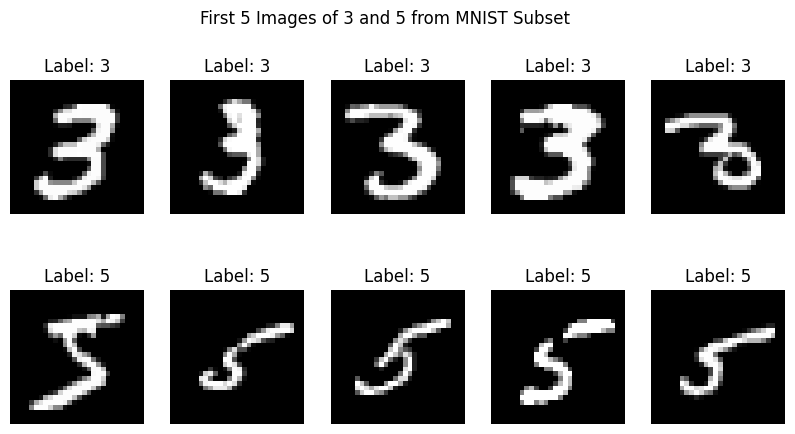

In [25]:
# Separate images for label 3 and label 5
images_3 = X_35[y_35 == 3]  # Get all images with label 3
images_5 = X_35[y_35 == 5]  # Get all images with label 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()


## Step - 2 - Initializing the Weights for 3 and 5 Classification:

In [26]:
# Initialize weights and bias for 3 and 5 classification
weights_35 = np.zeros(X_35.shape[1])  # 784 weights (one for each pixel)
bias_35 = 0
learning_rate_35 = 0.1
epochs_35 = 100


## Step - 3 - Make a Decision function (re-using the previously defined function):

## Step - 4 - Implement the Perceptron Learning Algorithm (re-using the previously defined function):

## Training the Perceptron for 3 and 5 Classification

In [30]:
# After training the model with the perceptron_learning_algorithm for 3s and 5s
# Note: The decision_function and train_perceptron functions are assumed to be defined above.
weights_35, bias_35, accuracy_35 = train_perceptron(X_35, y_35_binary, weights_35, bias_35, learning_rate_35, epochs_35)

# Evaluate the model using the new function
print("The Final Accuracy for 3s and 5s classification is: ", accuracy_35 * 100)


The Final Accuracy for 3s and 5s classification is:  99.96351696461146


## Step 6: Visualize Misclassified Images for 3 and 5 Classification

Final Accuracy for 3s and 5s: 0.9916


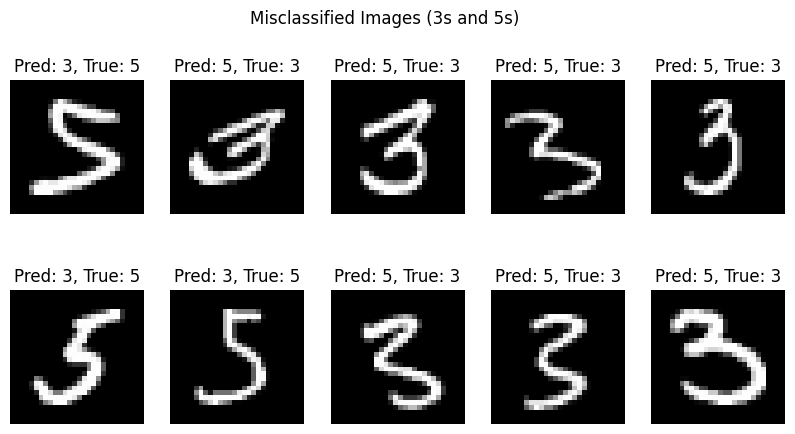

In [29]:
# Get predictions for all data points (3s and 5s)
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

# Calculate final accuracy
final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy for 3s and 5s: {final_accuracy_35:.4f}")

# Step 6: Visualize Misclassified Images
misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):  # Show 10 misclassified images
        # Original label from y_35 (3 or 5), predicted label is binary (0 or 1)
        # Map binary prediction back to original label for display
        predicted_original_label = 3 if y_pred_35[idx] == 0 else 5
        true_original_label = y_35[idx]

        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {predicted_original_label}, True: {true_original_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3s and 5s)")
    plt.show()
else:
    print("All images of 3s and 5s were correctly classified!")
